In [1]:
#Standard Packages:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
from dateutil.relativedelta import relativedelta
from pandas.tseries.offsets import MonthEnd

#YahooFinance:
from pandas_datareader import data as pdr
import yfinance as yf


#Statsmodels:
import statsmodels.api as sma
import statsmodels as sm
from statsmodels import tsa
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import t, probplot

In [2]:
#Importing historic price data using yfinance
ticker = 'BBNI.JK'
stockTicker = yf.Ticker(ticker)
hist = stockTicker.history(period='1y')

#For forecasting purposes I reset my index to integers:
hist = hist.reset_index()

In [3]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = hist.index, y = hist['Close'], mode = 'lines'))

fig.update_layout(
    autosize=False,
    width=800,
    height=500,
    xaxis_title = 'Days',
    yaxis_title = 'Price $',
    title = f'{ticker} Historic Stock Price'
)

fig.show()

In [4]:
#Order of integration
adf = adfuller(x=hist['Close'],
                  autolag='BIC')
print(f'ADF Statistic: {adf[0]}')
print(f'p-value: {adf[1]}')

ADF Statistic: -3.0974310227106687
p-value: 0.02674388936764518


In [5]:
# Membuat kolom baru berisi selisih harga (differencing)
hist['Diff_1'] = hist['Close']

# Uji kembali dengan ADF pada data yang sudah di-diff
adf_diff = adfuller(hist['Diff_1'].dropna(), autolag='BIC')

print(f'ADF Statistic (Setelah Diff): {adf_diff[0]}')
print(f'p-value (Setelah Diff): {adf_diff[1]}')

ADF Statistic (Setelah Diff): -3.0974310227106687
p-value (Setelah Diff): 0.02674388936764518


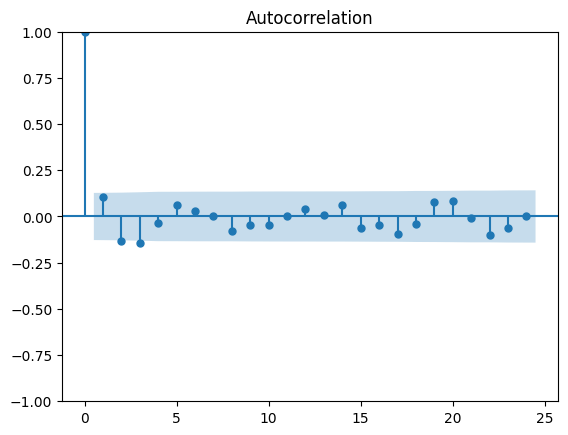

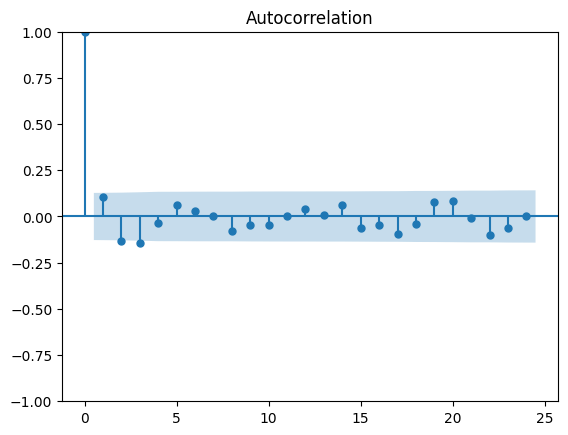

In [6]:
# Gunakan .diff() dan .dropna() agar data stasioner
sma.graphics.tsa.plot_acf(hist['Close'].diff().dropna())

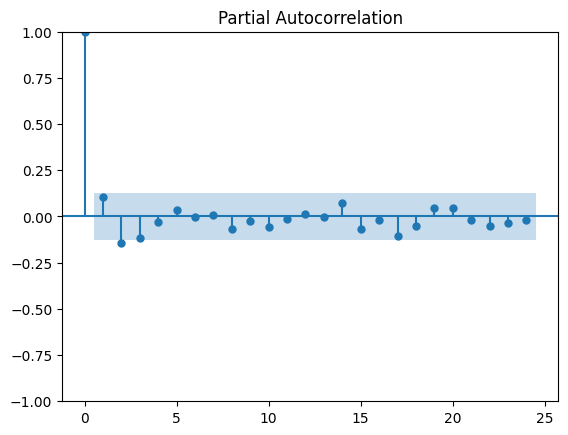

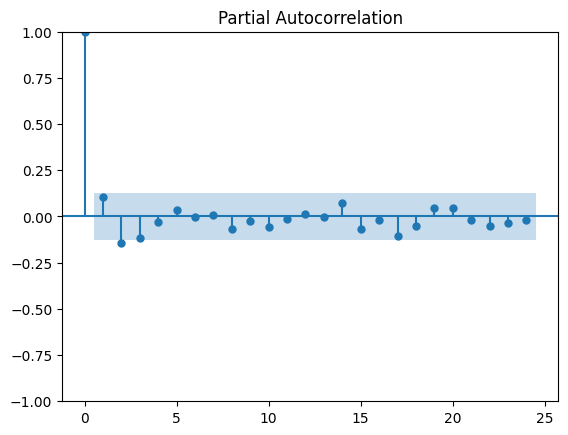

In [7]:
# Plot PACF pada data yang sudah stasioner
sma.graphics.tsa.plot_pacf(hist['Close'].diff().dropna())

In [8]:
#Significant AR lags:
pacf_coef = pacf(hist['Close'].diff().dropna(), alpha=.05)
sig_pacf = []
for i in range(1, len(pacf_coef[0])):
    if pacf_coef[0][i] > (pacf_coef[1][i][1] - pacf_coef[0][i]):
        sig_pacf.append(i)
    elif pacf_coef[0][i] < (pacf_coef[1][i][0] - pacf_coef[0][i]):
        sig_pacf.append(i)

sig_pacf

[2]

In [9]:
def get_arima_price(df, fact, forecast_steps):

    #MA Lags
    acf_coef = acf(df[fact].diff().dropna(), alpha=.05)
    sig_acf = []
    for i in range(1, len(acf_coef[0])):
        if acf_coef[0][i] > (acf_coef[1][i][1] - acf_coef[0][i]):
            sig_acf.append(i)
        elif acf_coef[0][i] < (acf_coef[1][i][0] - acf_coef[0][i]):
            sig_acf.append(i)

    #AR Lags
    pacf_coef = pacf(df[fact].diff().dropna(), alpha=.05)
    sig_pacf = []
    for i in range(1, len(pacf_coef[0])):
        if pacf_coef[0][i] > (pacf_coef[1][i][1] - pacf_coef[0][i]):
            sig_pacf.append(i)
        elif pacf_coef[0][i] < (pacf_coef[1][i][0] - pacf_coef[0][i]):
            sig_pacf.append(i)

    #Order of integration
    adf = adfuller(x=df[fact],
                  autolag='BIC')
    order = 0
    if adf[0] < adf[4]['5%']:
        order = 0
    else:
        order = 1

    #Trend indication
    if order == 1:
        trend = 't'
    else:
        trend = 'c'
    # Ambil nilai maksimal agar menjadi integer
    p = max(sig_pacf) if sig_pacf else 0
    q = max(sig_acf) if sig_acf else 0
    d = order # hasil dari pengecekan ADF

    model = ARIMA(endog = df[fact],
                  order = (p, d, q),
                  trend = trend).fit()

    forecast = model.get_forecast(forecast_steps, alpha=0.05)

    predict = model.predict()

    return forecast.summary_frame(), model.summary(), predict

In [10]:
# Mencoba prediksi untuk 30 hari ke depan
hasil_forecast, ringkasan, hasil_predict = get_arima_price(hist, 'Close', 30)

# Intip hasil prediksinya
print(hasil_forecast)

Close         mean     mean_se  mean_ci_lower  mean_ci_upper
237    4386.393638   80.428526    4228.756623    4544.030653
238    4365.660052  118.057703    4134.271206    4597.048898
239    4352.412358  139.662810    4078.678281    4626.146435
240    4345.483446  152.857583    4045.888089    4645.078803
241    4339.354004  163.265809    4019.358899    4659.349109
242    4333.671199  171.754781    3997.038014    4670.304384
243    4328.386461  178.773800    3977.996251    4678.776671
244    4323.470966  184.631217    3961.600430    4685.341502
245    4318.898859  189.552863    3947.382074    4690.415645
246    4314.646150  193.710032    3934.981463    4694.310837
247    4310.690526  197.235985    3924.115099    4697.265952
248    4307.011232  200.236425    3914.555051    4699.467414
249    4303.588966  202.796486    3906.115158    4701.062774
250    4300.405771  204.985565    3898.641447    4702.170095
251    4297.444947  206.860788    3892.005252    4702.884642
252    4294.690960  208.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning:

Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.



In [11]:
# 1. Jalankan fungsi untuk mendapatkan hasil
# Kita asumsikan memprediksi 30 hari ke depan
forecast_df, summary, predict_values = get_arima_price(hist, 'Close', 30)

# 2. Buat grafik perbandingan
fig = go.Figure()

# Garis Harga Asli
fig.add_trace(go.Scatter(
    x=hist['Date'],
    y=hist['Close'],
    mode='lines',
    name='Harga Asli (Actual)',
    line=dict(color='blue')
))

# Garis Prediksi pada data historis (In-sample prediction)
fig.add_trace(go.Scatter(
    x=hist['Date'],
    y=predict_values,
    mode='lines',
    name='Prediksi Model (In-sample)',
    line=dict(color='orange', dash='dot')
))

# Garis Peramalan Masa Depan (Out-of-sample forecast)
# Kita buat index tanggal untuk masa depan
last_date = hist['Date'].iloc[-1]
forecast_dates = [last_date + relativedelta(days=i) for i in range(1, 31)]

fig.add_trace(go.Scatter(
    x=forecast_dates,
    y=forecast_df['mean'],
    mode='lines',
    name='Ramalan 30 Hari (Forecast)',
    line=dict(color='red', width=3)
))

# Menambahkan Area Ketidakpastian (Confidence Interval)
fig.add_trace(go.Scatter(
    x=forecast_dates + forecast_dates[::-1],
    y=pd.concat([forecast_df['mean_ci_upper'], forecast_df['mean_ci_lower'][::-1]]),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.1)',
    line=dict(color='rgba(255, 0, 0, 0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Batas Ketidakpastian'
))

fig.update_layout(
    title='Analisis Prediksi Harga Saham BBNI.JK (Model ARIMA)',
    xaxis_title='Tanggal',
    yaxis_title='Harga (IDR)',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning:

Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.



In [13]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = hist.index, y = hist['Close'], mode = 'lines', name = 'Observed'))
fig.add_trace(go.Scatter(x = hasil_predict.index[1:], y = hasil_predict[1:], mode = 'lines', name = 'ARIMA Model Prediction'))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean'], mode = 'lines', name = 'ARIMA Model Forecast'))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean_ci_lower'], mode = 'lines', name = 'Forecast Error', line=dict(color='darkblue')))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean_ci_upper'], mode = 'lines', line=dict(color='darkblue'), showlegend = False))
fig.add_trace(go.Scatter(x = [hasil_predict.index[-1], forecast_df.index[0]], y = [hasil_predict.iloc[-1], forecast_df['mean'].iloc[0]], mode = 'lines', name = 'ARIMA Model 1-Day Forecast'))
fig.add_trace(go.Scatter(x = forecast_df.index[:4], y = forecast_df['mean'].iloc[:4], mode = 'lines', name = 'ARIMA Model 4-Day Forecast (Higher Accuracy)'))

fig.update_layout(
    autosize=False,
    width=800,
    height=500,
    xaxis_title = 'Days',
    yaxis_title = 'Price $',
    title = f'{ticker} Stock Price'
)

fig.show()

In [14]:
print(hasil_forecast['mean'])

237    4386.393638
238    4365.660052
239    4352.412358
240    4345.483446
241    4339.354004
242    4333.671199
243    4328.386461
244    4323.470966
245    4318.898859
246    4314.646150
247    4310.690526
248    4307.011232
249    4303.588966
250    4300.405771
251    4297.444947
252    4294.690960
253    4292.129360
254    4289.746707
255    4287.530501
256    4285.469114
257    4283.551731
258    4281.768292
259    4280.109440
260    4278.566472
261    4277.131292
262    4275.796370
263    4274.554703
264    4273.399776
265    4272.325529
266    4271.326327
Name: mean, dtype: float64


In [15]:
# 1. Simpan tabel forecast ke dalam file CSV
# Kita ambil hasil dari variabel forecast_df yang berisi mean dan confidence interval
forecast_df.to_excel('hasil_prediksi_arima_bbni.xlsx', index=True)

# 2. Perintah untuk mengunduh file ke komputer lokal (khusus Google Colab)
from google.colab import files
files.download('hasil_prediksi_arima_bbni.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# 1. Ambil hanya kolom 'mean' saja
prediksi_hanya_mean = hasil_forecast[['mean']]

# 2. Simpan ke file XLSX
file_output = 'prediksi_mean_bbni.xlsx'
prediksi_hanya_mean.to_excel(file_output, index=True)

# 3. Download file ke komputer lokal
from google.colab import files
files.download(file_output)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# 1. Pastikan library openpyxl terinstal (untuk menulis file Excel)
!pip install openpyxl

# Hapus informasi timezone dari kolom 'Date'
hist['Date'] = hist['Date'].dt.tz_localize(None)

# 2. Simpan data 'hist' ke dalam format Excel
file_excel = f"{ticker}_data_historis_1y.xlsx"
hist.to_excel(file_excel, index=False)

# 3. Download file ke komputer lokal
from google.colab import files
files.download(file_excel)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>